# 06 - Baseline Defect Detection

**Purpose:** Build an interpretable OpenCV baseline before deep anomaly detection.

**Expected output:** Normal reference image, anomaly map, heatmap overlay, metrics, confusion matrix, threshold sensitivity, and error review.

**Platform connection:** This is the fallback inspection engine and a sanity check for PaDiM.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from ml.dataset_loader import load_bottle_dataframe
from ml.baseline_detector import build_reference_image, anomaly_map, anomaly_score, heatmap_overlay, threshold_from_scores, predict_from_score


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Build Normal Reference


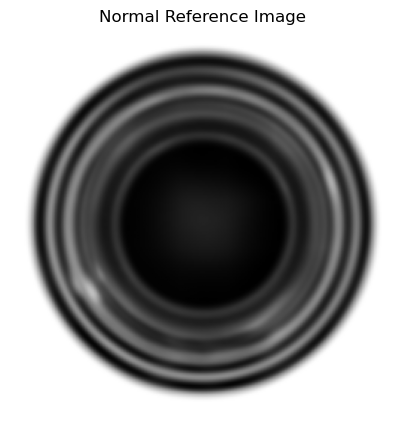

,train_good_images,test_images,reference_shape
0,209,83,"(256, 256)"


In [2]:
dataset_df = load_bottle_dataframe()
train_good = dataset_df[(dataset_df["split"].eq("train")) & (dataset_df["label"].eq("good"))]
test_df = dataset_df[dataset_df["split"].eq("test")].reset_index(drop=True)
reference = build_reference_image(train_good["image_path"].tolist(), size=IMAGE_SIZE)
plt.figure(figsize=(5, 5))
plt.imshow(reference, cmap="gray")
plt.title("Normal Reference Image")
plt.axis("off")
plt.show()
display(pd.DataFrame([{"train_good_images": len(train_good), "test_images": len(test_df), "reference_shape": str(reference.shape)}]))


## Score Test Images


In [3]:
train_scores = []
for path in train_good["image_path"].tolist():
    train_scores.append(anomaly_score(anomaly_map(cv2.imread(str(path)), reference, size=IMAGE_SIZE)))
threshold = threshold_from_scores(train_scores, percentile=99)
rows = []
for _, row in test_df.iterrows():
    img_bgr = cv2.imread(row["image_path"])
    diff = anomaly_map(img_bgr, reference, size=IMAGE_SIZE)
    score = anomaly_score(diff)
    pred = predict_from_score(score, threshold)
    rows.append({**row.to_dict(), "anomaly_score": score, "prediction": pred, "prediction_name": "defective" if pred else "good"})
results_df = pd.DataFrame(rows)
display(results_df[["label", "target_name", "anomaly_score", "prediction_name"]].head(12))
display(pd.DataFrame([{"decision_threshold": round(float(threshold), 4), "train_score_mean": round(float(np.mean(train_scores)), 4), "train_score_max": round(float(np.max(train_scores)), 4)}]))


,label,target_name,anomaly_score,prediction_name
0,good,good,59.052139,good
1,good,good,28.728897,good
2,good,good,51.760624,good
3,good,good,40.923981,good
4,good,good,33.384781,good
5,good,good,41.319168,good
6,good,good,44.745102,good
7,good,good,55.032749,good
8,good,good,44.893600,good
9,good,good,41.842106,good


,decision_threshold,train_score_mean,train_score_max
0,78.4423,45.5188,83.4221


## Metrics, ROC, And Confusion Matrix


,accuracy,precision,recall,f1_score,roc_auc
0,0.5181,1.0,0.3651,0.5349,0.9206


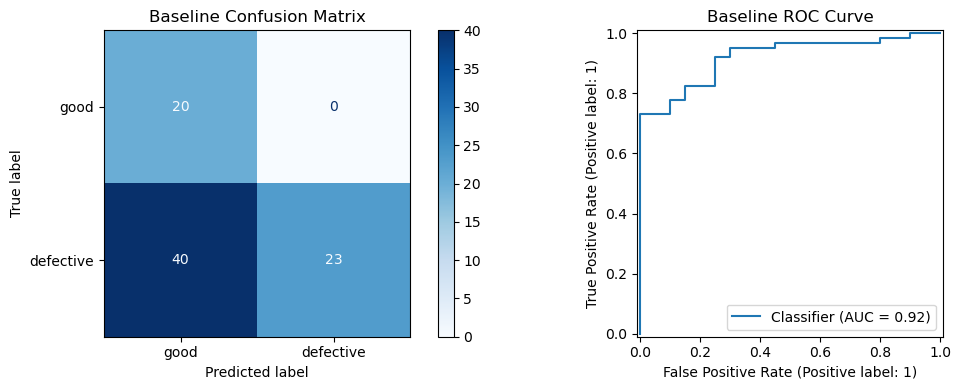

In [4]:
y_true = results_df["target"].astype(int).tolist()
y_pred = results_df["prediction"].astype(int).tolist()
metrics_df = pd.DataFrame([{
    "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
    "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
    "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
    "f1_score": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
    "roc_auc": round(float(roc_auc_score(y_true, results_df["anomaly_score"])), 4),
}])
display(metrics_df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["good", "defective"], cmap="Blues", ax=axes[0])
axes[0].set_title("Baseline Confusion Matrix")
RocCurveDisplay.from_predictions(y_true, results_df["anomaly_score"], ax=axes[1])
axes[1].set_title("Baseline ROC Curve")
plt.tight_layout()
plt.show()


## Heatmap And Decision Reasoning


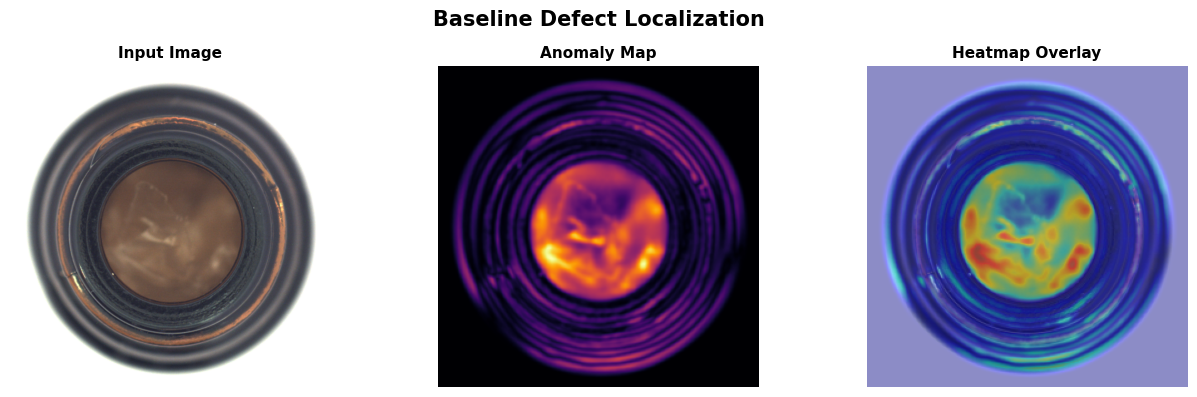

,label,anomaly_score,threshold,decision,reason
0,contamination,123.2197,78.4423,defective,score is above threshold


In [5]:
sample = results_df[results_df["target"].eq(1)].sort_values("anomaly_score", ascending=False).iloc[0]
image_bgr = cv2.imread(sample["image_path"])
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
diff = anomaly_map(image_bgr, reference, size=IMAGE_SIZE)
overlay_rgb = cv2.cvtColor(heatmap_overlay(image_bgr, diff), cv2.COLOR_BGR2RGB)
show_grid([("Input Image", image_rgb, None), ("Anomaly Map", diff, "inferno"), ("Heatmap Overlay", overlay_rgb, None)], cols=3, figsize=(13, 4), suptitle="Baseline Defect Localization")
display(pd.DataFrame([{"label": sample["label"], "anomaly_score": round(float(sample["anomaly_score"]), 4), "threshold": round(float(threshold), 4), "decision": sample["prediction_name"], "reason": "score is above threshold" if sample["anomaly_score"] > threshold else "score is below threshold"}]))


## Threshold Sensitivity And Error Cases


,percentile,threshold,fail_count,f1_score,recall
0,90.0,57.4179,53,0.8621,0.7937
1,95.0,61.9918,44,0.8224,0.6984
2,97.0,64.7754,39,0.7647,0.6190
3,99.0,78.4423,23,0.5349,0.3651
4,99.5,79.4484,23,0.5349,0.3651


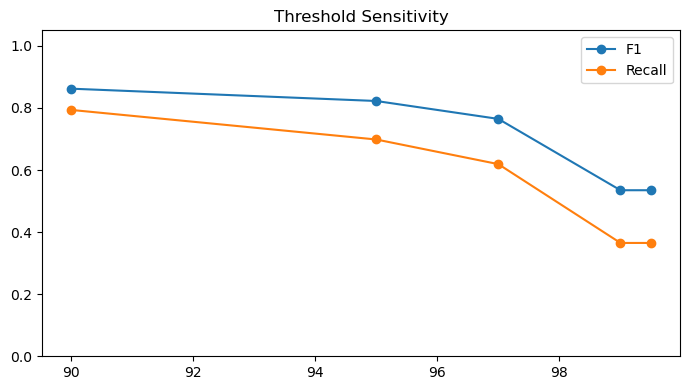

,label,target_name,anomaly_score,prediction_name,image_path
21,broken_large,defective,77.788429,good,C:\Users\HP\Desktop\springboard\visioninspect-...
24,broken_large,defective,77.118446,good,C:\Users\HP\Desktop\springboard\visioninspect-...
25,broken_large,defective,61.704140,good,C:\Users\HP\Desktop\springboard\visioninspect-...
27,broken_large,defective,72.482155,good,C:\Users\HP\Desktop\springboard\visioninspect-...
28,broken_large,defective,73.478279,good,C:\Users\HP\Desktop\springboard\visioninspect-...


In [6]:
rows = []
for percentile in [90, 95, 97, 99, 99.5]:
    t = threshold_from_scores(train_scores, percentile=percentile)
    preds = [predict_from_score(score, t) for score in results_df["anomaly_score"]]
    rows.append({"percentile": percentile, "threshold": round(float(t), 4), "fail_count": int(sum(preds)), "f1_score": round(float(f1_score(y_true, preds, zero_division=0)), 4), "recall": round(float(recall_score(y_true, preds, zero_division=0)), 4)})
sensitivity_df = pd.DataFrame(rows)
display(sensitivity_df)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sensitivity_df["percentile"], sensitivity_df["f1_score"], marker="o", label="F1")
ax.plot(sensitivity_df["percentile"], sensitivity_df["recall"], marker="o", label="Recall")
ax.set_title("Threshold Sensitivity")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()
errors_df = results_df[results_df["target"].astype(int) != results_df["prediction"].astype(int)]
display(Markdown("**No false positives or false negatives found for this baseline run.**") if errors_df.empty else errors_df[["label", "target_name", "anomaly_score", "prediction_name", "image_path"]].head())


## Business Interpretation Of Baseline Results

This converts baseline metrics into manufacturing inspection meaning.


,case,count,business meaning
0,true positive,23,defective product correctly caught
1,true negative,20,good product correctly passed
2,false positive,0,good product unnecessarily reviewed/reworked
3,false negative,40,defective product missed; highest quality risk


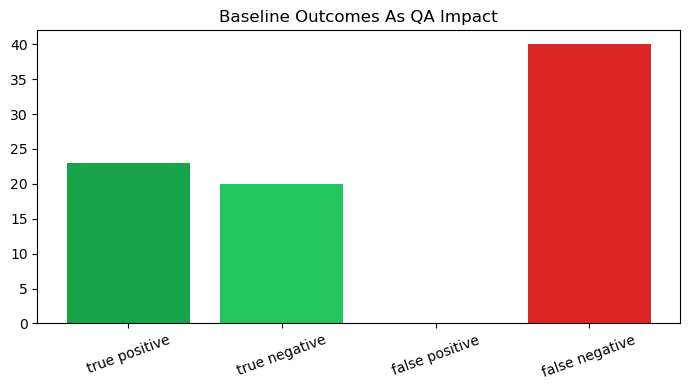

In [7]:
tp = int(((results_df["target"] == 1) & (results_df["prediction"] == 1)).sum())
tn = int(((results_df["target"] == 0) & (results_df["prediction"] == 0)).sum())
fp = int(((results_df["target"] == 0) & (results_df["prediction"] == 1)).sum())
fn = int(((results_df["target"] == 1) & (results_df["prediction"] == 0)).sum())

business_df = pd.DataFrame([
    {"case": "true positive", "count": tp, "business meaning": "defective product correctly caught"},
    {"case": "true negative", "count": tn, "business meaning": "good product correctly passed"},
    {"case": "false positive", "count": fp, "business meaning": "good product unnecessarily reviewed/reworked"},
    {"case": "false negative", "count": fn, "business meaning": "defective product missed; highest quality risk"},
])
display(business_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(business_df["case"], business_df["count"], color=["#16a34a", "#22c55e", "#f59e0b", "#dc2626"])
ax.set_title("Baseline Outcomes As QA Impact")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Validation Outcome

- The baseline gives explainable anomaly scoring.
- Threshold selection changes pass/fail behavior.
- Heatmaps provide visual evidence for QA review.
